In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 

In [3]:
# Settings for nice plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df = pd.read_csv("../data/claims_train.csv")

In [5]:
# --- A. GENERAL OVERVIEW ---
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Dataset Shape: (542410, 12)

Missing Values:
 IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64

Data Types:
 IDpol         float64
ClaimNb         int64
Exposure      float64
Area           object
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand       object
VehGas         object
Density         int64
Region         object
dtype: object


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\2552808269.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['ClaimNb'], palette='viridis')


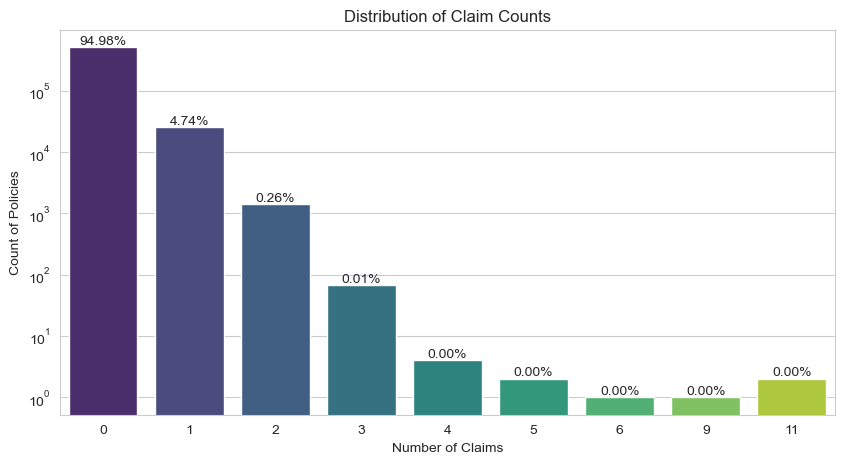

In [6]:
# --- B. TARGET VARIABLE ANALYSIS (ClaimNb) ---
# Goal: Show that this is NOT a normal distribution (it's Poisson/Zero-Inflated)
plt.figure(figsize=(10, 5))
ax = sns.countplot(x=df['ClaimNb'], palette='viridis')
plt.title('Distribution of Claim Counts')
plt.xlabel('Number of Claims')
plt.ylabel('Count of Policies')
plt.yscale('log') # Log scale helps visualize the rare 1, 2, 3, 4 claims

# Add percentages
total = len(df)
for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

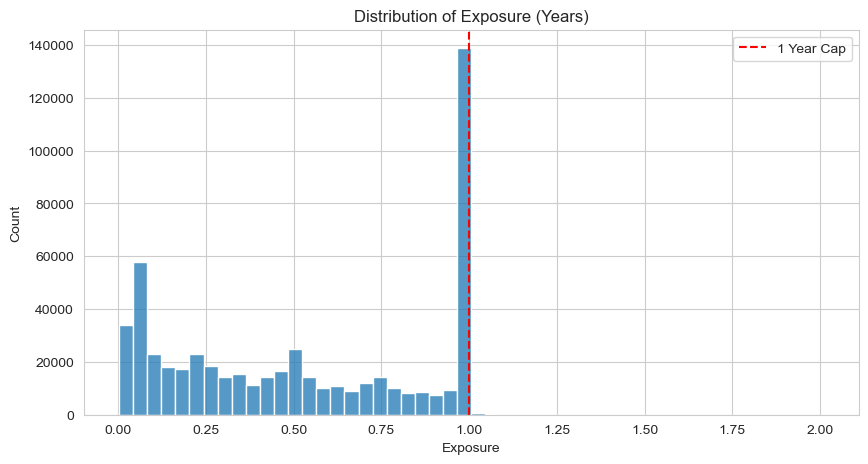

Policies with Exposure > 1 year: 994


In [7]:
# --- C. EXPOSURE ANALYSIS ---
# Goal: Check if we need to cap exposure or use it as a weight
plt.figure(figsize=(10, 5))
sns.histplot(df['Exposure'], bins=50, kde=False)
plt.title('Distribution of Exposure (Years)')
plt.xlabel('Exposure')
plt.axvline(1.0, color='red', linestyle='--', label='1 Year Cap')
plt.legend()
plt.show()

# Check for > 1.0 outliers
print(f"Policies with Exposure > 1 year: {len(df[df['Exposure'] > 1])}")

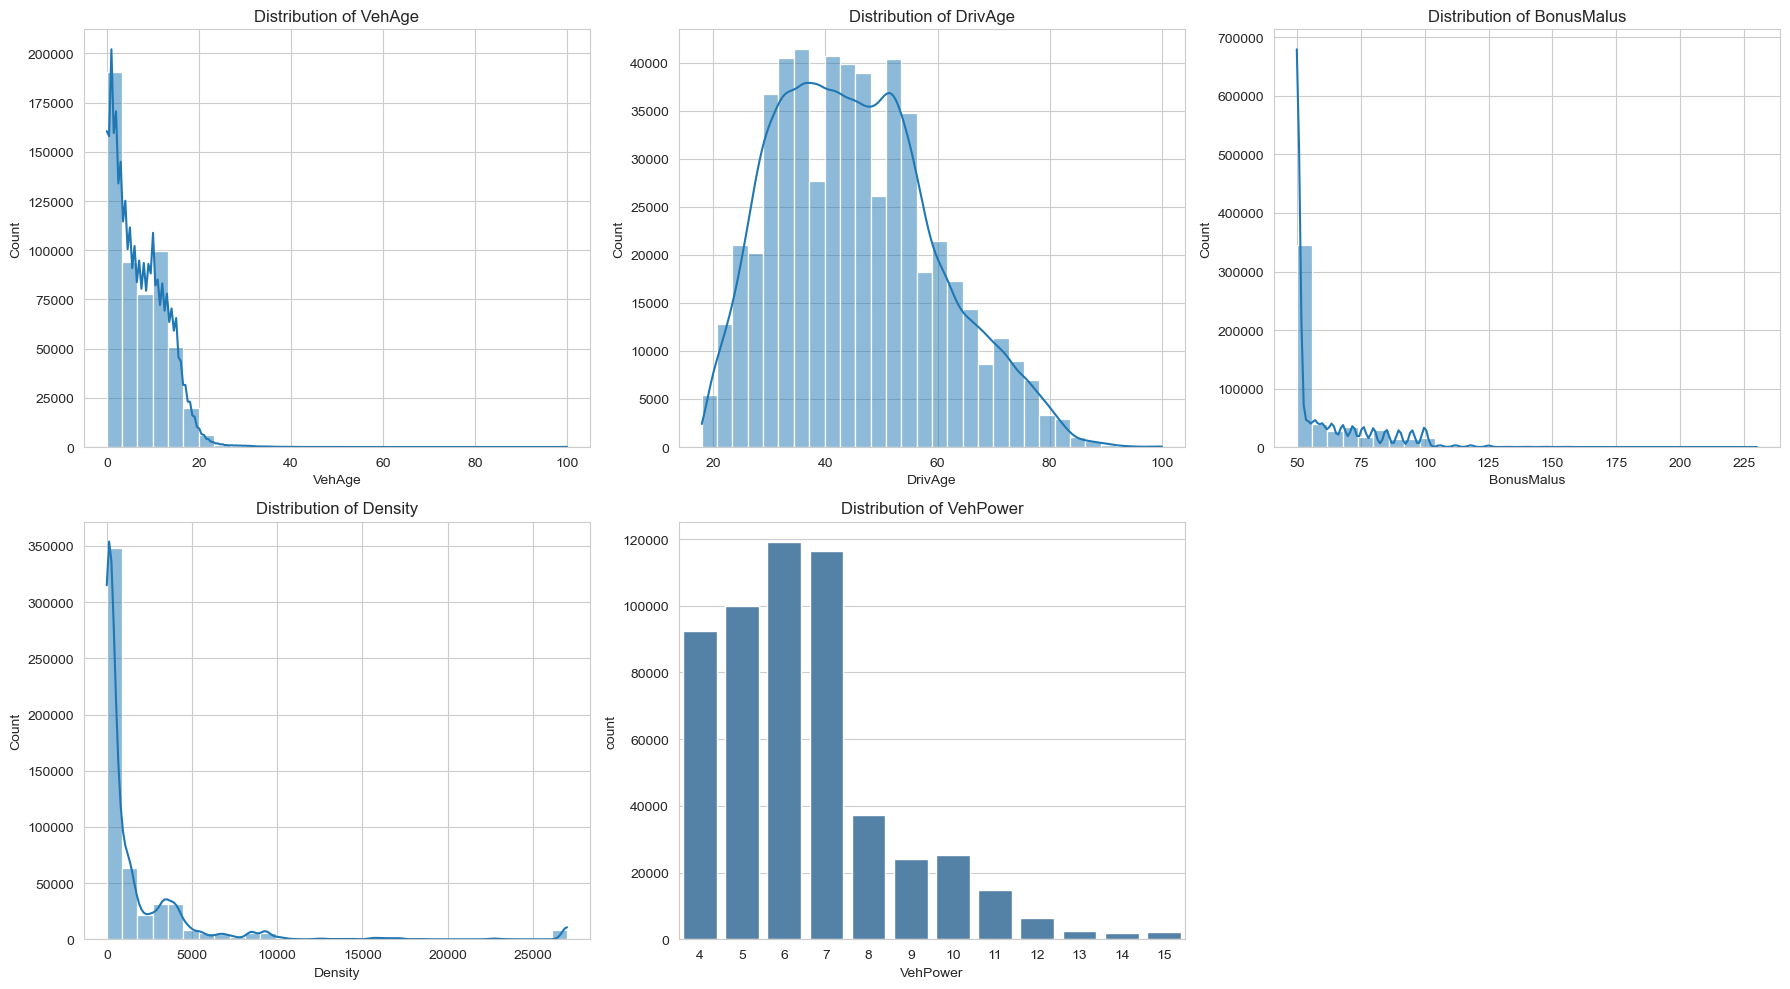

In [14]:
# --- D. NUMERIC FEATURES DISTRIBUTION (Improved) ---
num_cols = ['VehAge', 'DrivAge', 'BonusMalus', 'Density', 'VehPower']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    
    # SPECIAL HANDLING FOR VEHPOWER
    if col == 'VehPower':
        # Use countplot for discrete integer values
        # This removes the "wavy" KDE and treats 4, 5, 6 as distinct groups
        sns.countplot(x=df[col], ax=axes[i], color='steelblue')
    else:
        # Use standard histogram + KDE for continuous variables
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    
    axes[i].set_title(f'Distribution of {col}')


# Remove empty subplot
if len(num_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

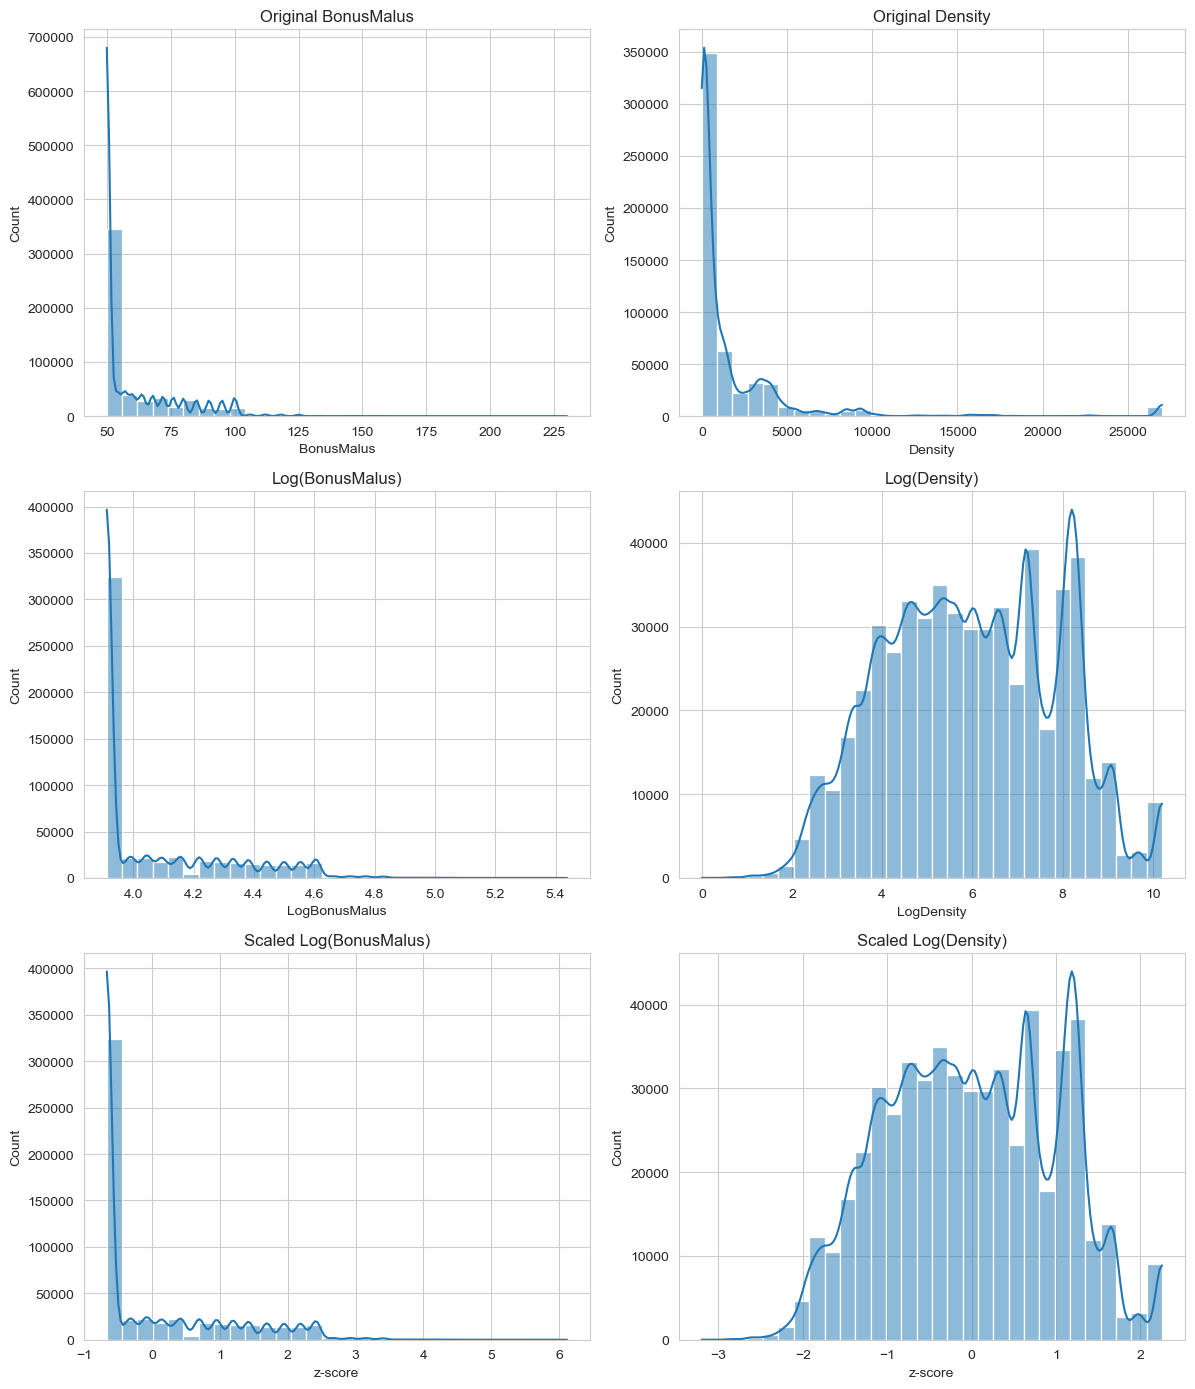

In [9]:
# -----------------------------
# Columns
# -----------------------------
num_cols = ['VehAge', 'DrivAge', 'BonusMalus', 'Density', 'VehPower']

# -----------------------------
# Prepare transformed data
# -----------------------------
df_plot = df[num_cols].copy()

# Log-transform
# We add these to df_plot
df_plot['LogBonusMalus'] = np.log(df_plot['BonusMalus'])
df_plot['LogDensity'] = np.log(df_plot['Density'])

# Define which columns we actually want to standardize
# We replace the original skew variables with their logged versions in the scaling list
cols_to_scale = ['VehAge', 'DrivAge', 'VehPower', 'LogBonusMalus', 'LogDensity']

# Standard scaling
scaler = StandardScaler()
# Fix: Scale the specific columns we prepared (including the logged ones)
scaled_vals = scaler.fit_transform(df_plot[cols_to_scale])

# Create DataFrame with proper column names
df_scaled = pd.DataFrame(
    scaled_vals,
    columns=[f"{c}_scaled" for c in cols_to_scale]
)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# --- Row 1: Original ---
for i, col in enumerate(['BonusMalus', 'Density']):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Original {col}")
    axes[i].set_xlabel(col)

# --- Row 2: Log-transformed ---
sns.histplot(df_plot['LogBonusMalus'], bins=30, kde=True, ax=axes[3])
axes[3].set_title("Log(BonusMalus)")
axes[3].set_xlabel("LogBonusMalus")

sns.histplot(df_plot['LogDensity'], bins=30, kde=True, ax=axes[4])
axes[4].set_title("Log(Density)")
axes[4].set_xlabel("LogDensity")

# --- Row 3: Scaled (z-score of LOGGED data) ---
# Now we access the scaled versions of the log columns
sns.histplot(df_scaled['LogBonusMalus_scaled'], bins=30, kde=True, ax=axes[6])
axes[6].set_title("Scaled Log(BonusMalus)")
axes[6].set_xlabel("z-score")

sns.histplot(df_scaled['LogDensity_scaled'], bins=30, kde=True, ax=axes[7])
axes[7].set_title("Scaled Log(Density)")
axes[7].set_xlabel("z-score")

# Remove unused axes
for j in [2, 5, 8]:
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\860578335.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, ax=axes[i], palette="hls")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\860578335.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, ax=axes[i], palette="hls")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\860578335.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, ax=axes[i], palette="hls")
C:\Users\Lenovo\AppData\Local\Temp

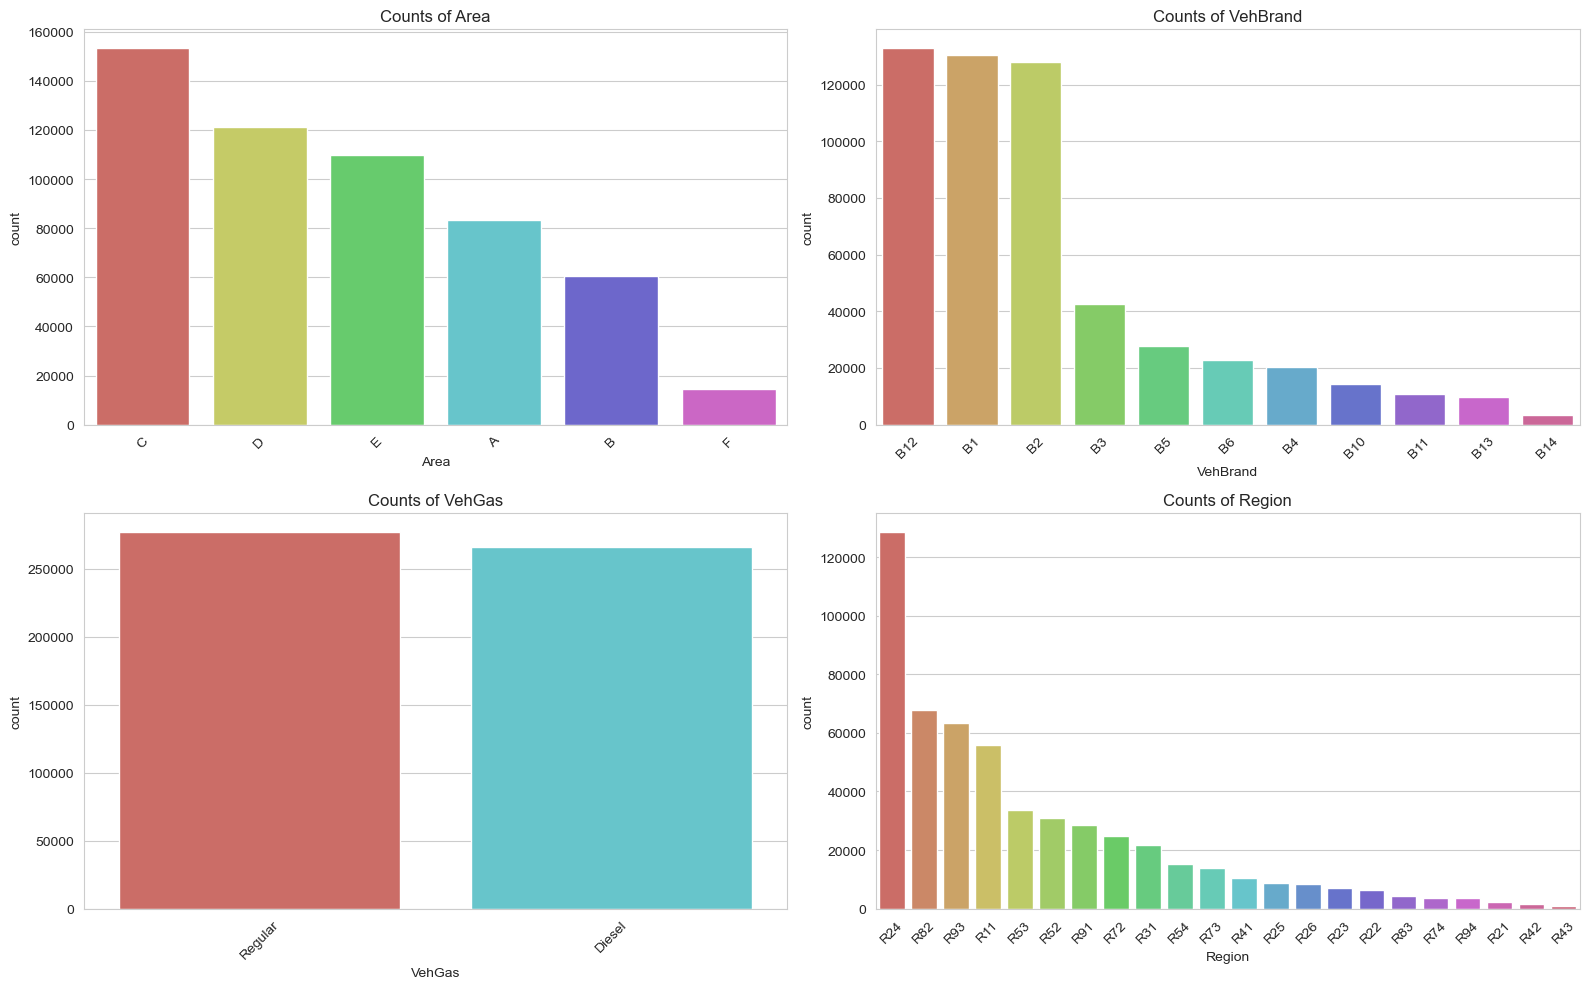

In [10]:
# --- E. CATEGORICAL FEATURES ---
# Goal: Check cardinality (Region/Brand) and balance (Gas)
cat_cols = ['Area', 'VehBrand', 'VehGas', 'Region']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Order by count
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, ax=axes[i], palette="hls")
    axes[i].set_title(f'Counts of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Generating Driver Age Risk Profile...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\1095608714.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_data = df_temp.groupby(feature).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\1095608714.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_data = df_temp.groupby(feature).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())


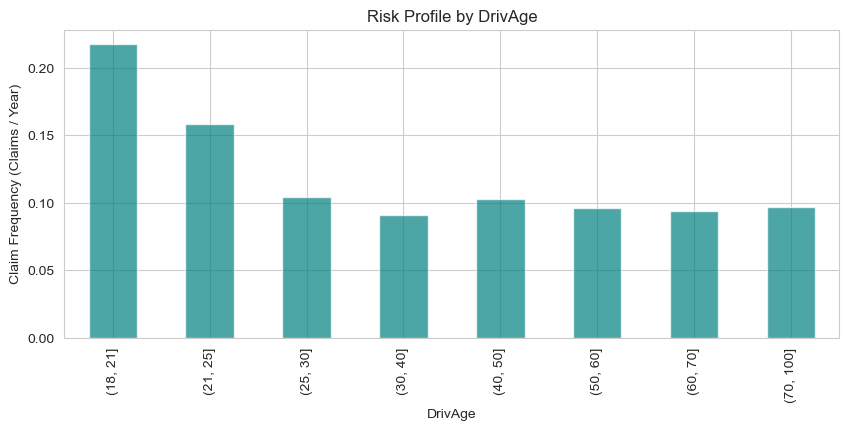

Generating Vehicle Power Risk Profile...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\1095608714.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_data = df_temp.groupby(feature).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())


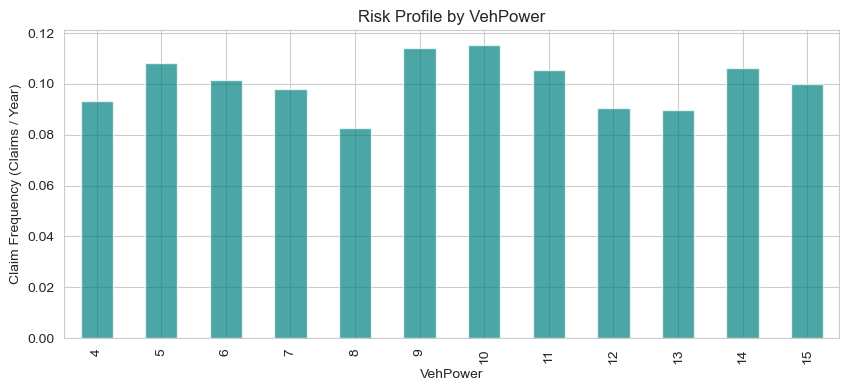

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\1095608714.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_data = df_temp.groupby(feature).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())


Generating Area Risk Profile...


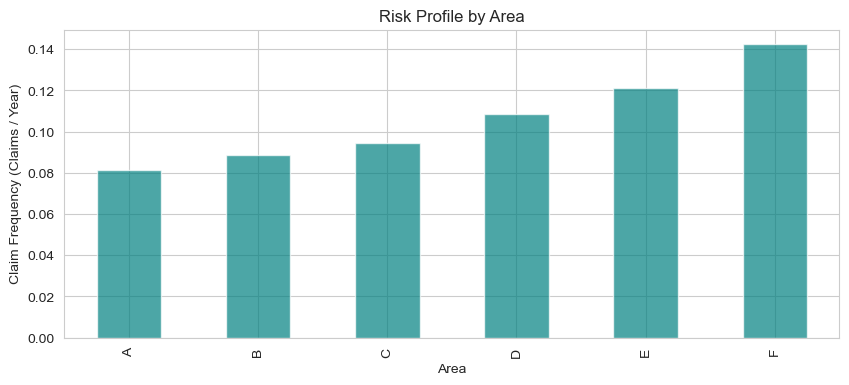

Generating BonusMalus Risk Profile...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\1095608714.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_data = df_temp.groupby(feature).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\1095608714.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_data = df_temp.groupby(feature).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())


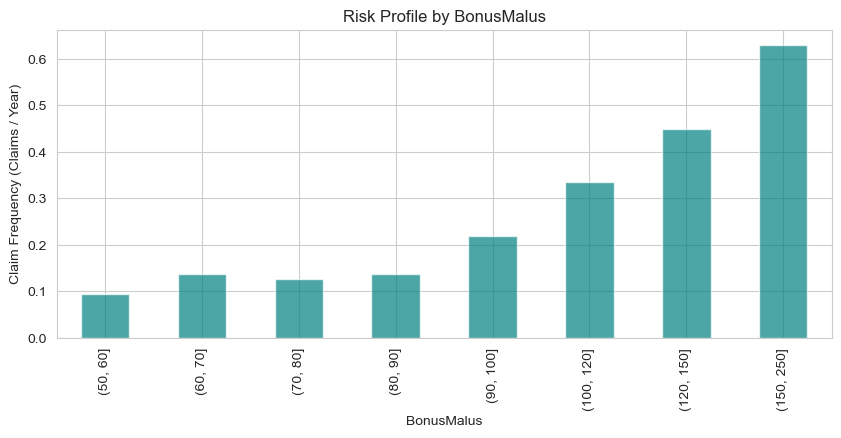

Generating Region Risk Profile...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2168\1095608714.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_data = df_temp.groupby(feature).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())


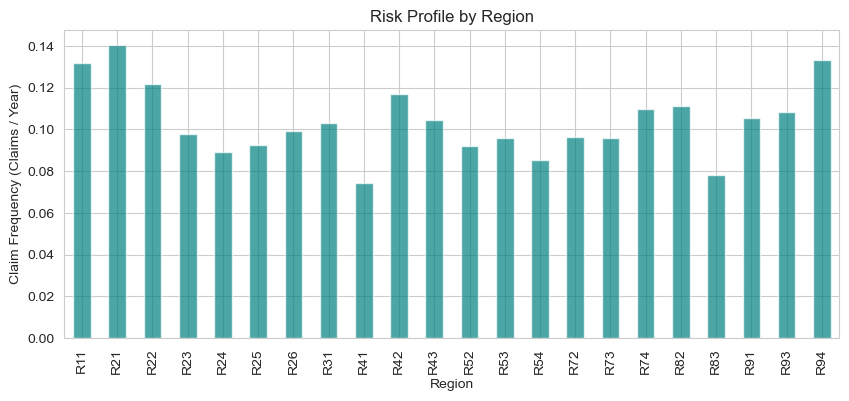

In [11]:
# Create a "Frequency" column just for visualization (ClaimNb / Exposure)
# We clip exposure to avoid division by tiny numbers or huge rates
df['Freq'] = df['ClaimNb'] / df['Exposure'].clip(lower=0.05) 

def plot_risk_trend(df, feature, bins=None, log_scale=False):
    """
    Plots the Mean Claim Frequency against a feature.
    This shows the 'Risk Profile'.
    """
    df_temp = df.copy()
    
    # If numeric and many values, bin it
    if bins:
        df_temp[feature] = pd.cut(df_temp[feature], bins=bins)
    
    # Calculate Mean Frequency per group
    # We calculate sum(claims) / sum(exposure) which is the actuarially correct mean
    group_data = df_temp.groupby(feature).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
    
    plt.figure(figsize=(10, 4))
    group_data.plot(kind='bar', color='teal', alpha=0.7)
    plt.ylabel('Claim Frequency (Claims / Year)')
    plt.title(f'Risk Profile by {feature}')
    if log_scale:
        plt.yscale('log')
    plt.show()

# --- GENERATE THE PLOTS ---

# 1. Driver Age (The U-Shape)
# Hypothesis: Young drivers crash more. Old drivers crash more. Middle are safe.
print("Generating Driver Age Risk Profile...")
age_bins = [18, 21, 25, 30, 40, 50, 60, 70, 100]
plot_risk_trend(df, 'DrivAge', bins=age_bins)

# 2. Vehicle Power (Monotonic?)
# Hypothesis: Higher power = higher speed = more accidents.
print("Generating Vehicle Power Risk Profile...")
# Note: We treat this as categorical/discrete here, so no bins needed
plot_risk_trend(df, 'VehPower')

# 3. Area (The Ordinal Proof)
# Hypothesis: A is safest, F is riskiest. If true, we can map A->1, B->2...
print("Generating Area Risk Profile...")
plot_risk_trend(df, 'Area')

# 4. Bonus Malus (The Strongest Predictor)
# Hypothesis: High Malus (>100) should have massively higher risk.
print("Generating BonusMalus Risk Profile...")
# We use broad bins to capture the tail
bm_bins = [50, 60, 70, 80, 90, 100, 120, 150, 250]
plot_risk_trend(df, 'BonusMalus', bins=bm_bins)

# 5. Region (Cardinality Check)
# Just to see if some regions are inherently riskier
print("Generating Region Risk Profile...")
# We assume Region is categorical
plot_risk_trend(df, 'Region')

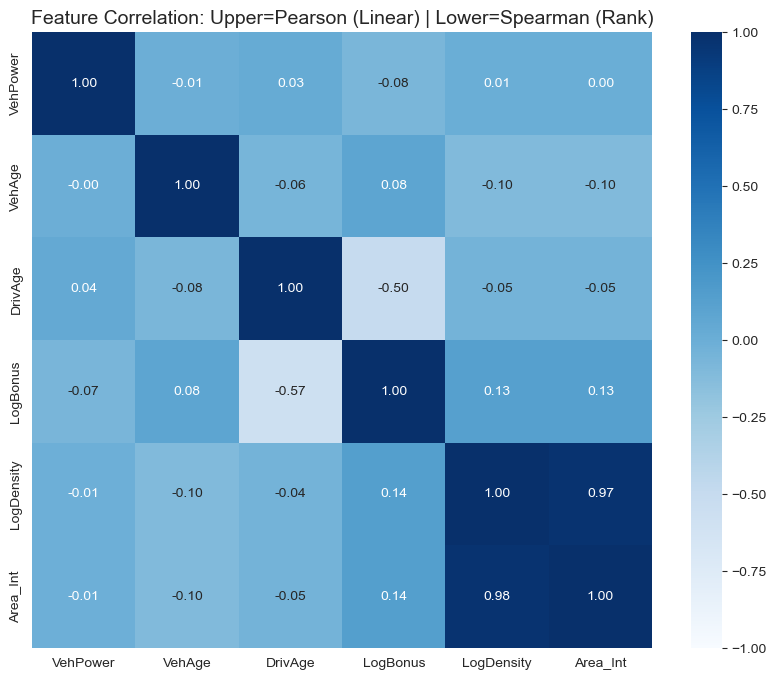

In [12]:
# --- PHASE 3.5: DUAL CORRELATION HEATMAP ---

# 1. Define the numeric dataframe (same as before)
df_corr = df.copy()
area_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6}
df_corr['Area_Int'] = df_corr['Area'].map(area_map)
df_corr['LogDensity'] = np.log1p(df_corr['Density'])
df_corr['LogBonus'] = np.log(df_corr['BonusMalus'])

cols_to_corr = ['VehPower', 'VehAge', 'DrivAge', 
                'LogBonus', 'LogDensity', 'Area_Int']

# 2. Calculate both matrices
pearson = df_corr[cols_to_corr].corr(method='pearson')
spearman = df_corr[cols_to_corr].corr(method='spearman')

# 3. Combine them into one matrix
# We create a new matrix that takes the Upper Triangle from Pearson 
# and the Lower Triangle from Spearman
combined_corr = pd.DataFrame(np.tril(spearman, k=-1) + np.triu(pearson, k=0),
                             columns=cols_to_corr, index=cols_to_corr)

# 4. Plotting
plt.figure(figsize=(10, 8))
ax = sns.heatmap(combined_corr, annot=True, fmt=".2f", cmap='Blues', vmin=-1, vmax=1)

# Add a title to explain the split
plt.title("Feature Correlation: Upper=Pearson (Linear) | Lower=Spearman (Rank)", fontsize=14)

# Optional: Add text to the plot to guide the reader
# This places text in the empty diagonal space if needed, or just relies on the title
plt.show()

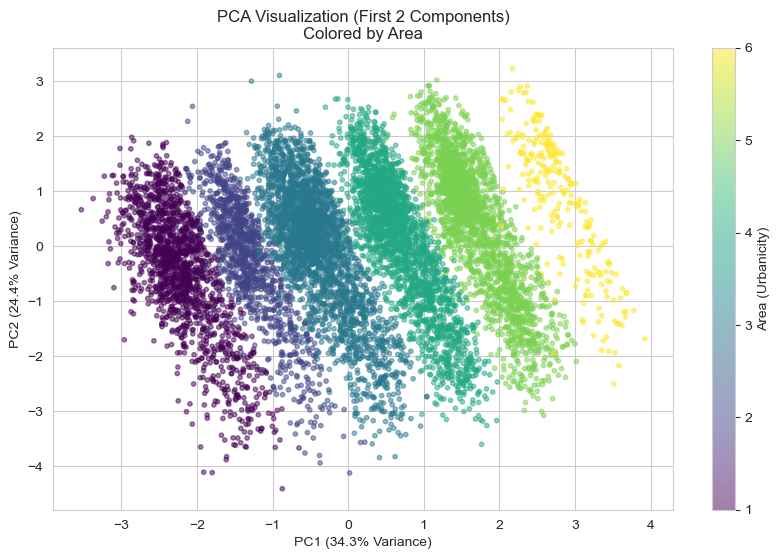


=== Cluster Profiles (Centroids) ===
         VehPower    VehAge    DrivAge  LogBonus  LogDensity  Area_Int  \
Cluster                                                                  
0        6.584615  5.846154  49.808615  3.963076    7.716317  4.568615   
1        6.506883  7.207149  49.197158  3.961358    4.494751  2.172513   
2        6.101069  7.801870  31.854408  4.411323    6.645171  3.779163   

          ClaimNb  
Cluster            
0        0.054154  
1        0.049956  
2        0.066785  


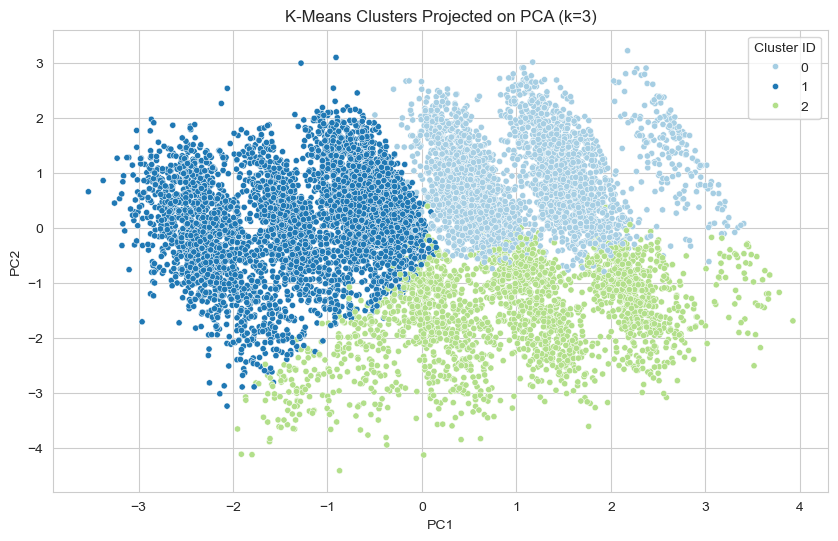

In [13]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- DATA PREPARATION FOR PCA/CLUSTERING ---
# We need a numeric matrix. Let's prepare a sample.
sample_size = 10000
df_sample = df_corr.sample(n=sample_size, random_state=42).copy()

# Select features for structure analysis (exclude targets like ClaimNb/Exposure)
features = ['VehPower', 'VehAge', 'DrivAge', 'LogBonus', 'LogDensity', 'Area_Int']
X_sample = df_sample[features]

# Standardize (PCA/KMeans are sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# --- A. PCA VISUALIZATION ---
# 1. Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Plot PCA
plt.figure(figsize=(10, 6))
# Color points by Area to see if structure aligns with urbanization
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_sample['Area_Int'], 
                      cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Area (Urbanicity)')
plt.title('PCA Visualization (First 2 Components)\nColored by Area')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.show()

# --- B. K-MEANS CLUSTERING ---
# 1. Run KMeans (Let's try 3 clusters: Low, Med, High risk profiles?)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_sample['Cluster'] = clusters

# 2. Analyze the Clusters (Who are they?)
# We group by cluster and check the mean of features to "name" them
cluster_profile = df_sample.groupby('Cluster')[features + ['ClaimNb']].mean()
print("\n=== Cluster Profiles (Centroids) ===")
print(cluster_profile)

# 3. Visualize Clusters on PCA space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Paired', s=20)
plt.title('K-Means Clusters Projected on PCA (k=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster ID')
plt.show()